In [ ]:
# Importing all required libraries
import pandas as pd
import numpy as np
import os

print("All libraries imported successfully!")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version  : {np.__version__}")

All libraries imported successfully!
Pandas version : 3.0.0
NumPy version  : 2.4.2


In [2]:
# Creating a deliberately messy dataset
# Every problem is intentionally added for cleaning practice

messy_data = {
    'customer_id': [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        3, 5,           # duplicate rows
        11, 12, 13
    ],
    'name': [
        'alice', 'BOB', 'Charlie', 'DIANA', 'eve',
        'Frank', 'GRACE', 'henry', 'IVY', 'jack',
        'Charlie', 'eve',  # duplicates
        'Karen', None, 'MIKE'   # missing value
    ],
    'age': [
        25, 30, 22, 45, 200,   # 200 is an outlier
        35, 28, -5, 40, 33,    # -5 is invalid
        22, 200,               # duplicates
        29, 31, 999            # 999 is an outlier
    ],
    'email': [
        'alice@gmail.com', 'BOB@GMAIL.COM', 'charlie@gmail.com',
        'diana@gmail.com', 'EVE@GMAIL.COM', 'frank@gmail.com',
        'grace@gmail.com', None, 'ivy@gmail.com', 'jack@gmail.com',
        'charlie@gmail.com', 'EVE@GMAIL.COM',
        'karen@gmail.com', 'liam@gmail.com', None  # missing
    ],
    'gender': [
        'Female', 'MALE', 'male', 'Female', 'female',
        'Male', 'FEMALE', 'Male', 'female', 'MALE',
        'male', 'female',
        'Female', 'Male', 'MALE'
    ],
    'salary': [
        '50000', '60000', '45000', '80000', '55000',
        '70000', '48000', 'seventy',   # wrong dtype — string word
        '90000', '62000',
        '45000', '55000',
        '53000', None,       # missing salary
        '1000000'            # outlier salary
    ],
    'join_date': [
        '2021-01-15', '2020-05-22', '2019-11-30', '2022-03-10', '2021-07-18',
        '2020-12-01', '2021-04-25', '2023-06-14', '2022-09-09', '2020-08-30',
        '2019-11-30', '2021-07-18',
        '2023/01/10',    # inconsistent date format
        '15-04-2022',    # another inconsistent format
        '2021-02-28'
    ],
    'city': [
        'new york', 'LOS ANGELES', 'chicago', 'HOUSTON', 'Phoenix',
        'philadelphia', 'SAN ANTONIO', 'San Diego', 'dallas', 'SAN JOSE',
        'chicago', 'Phoenix',
        'NEW YORK', 'los angeles', 'CHICAGO'
    ]
}

# DataFrame banao
df_messy = pd.DataFrame(messy_data)

# CSV save karo
df_messy.to_csv('messy_data.csv', index=False)

print("Messy CSV created and saved as 'messy_data.csv'")
print(f"Shape : {df_messy.shape[0]} rows x {df_messy.shape[1]} columns")
print("\nFirst 10 rows of messy data:")
print(df_messy.head(10))

Messy CSV created and saved as 'messy_data.csv'
Shape : 15 rows x 8 columns

First 10 rows of messy data:
   customer_id     name  age              email  gender   salary   join_date  \
0            1    alice   25    alice@gmail.com  Female    50000  2021-01-15   
1            2      BOB   30      BOB@GMAIL.COM    MALE    60000  2020-05-22   
2            3  Charlie   22  charlie@gmail.com    male    45000  2019-11-30   
3            4    DIANA   45    diana@gmail.com  Female    80000  2022-03-10   
4            5      eve  200      EVE@GMAIL.COM  female    55000  2021-07-18   
5            6    Frank   35    frank@gmail.com    Male    70000  2020-12-01   
6            7    GRACE   28    grace@gmail.com  FEMALE    48000  2021-04-25   
7            8    henry   -5                NaN    Male  seventy  2023-06-14   
8            9      IVY   40      ivy@gmail.com  female    90000  2022-09-09   
9           10     jack   33     jack@gmail.com    MALE    62000  2020-08-30   

           ci

In [3]:
# Load the messy CSV file
df = pd.read_csv('messy_data.csv')

print("=" * 60)
print("INITIAL DATA INSPECTION")
print("=" * 60)

print(f"\nShape            : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn Names     : {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows   : {df.duplicated().sum()}")
print(f"\nFirst 5 Rows:")
print(df.head())

INITIAL DATA INSPECTION

Shape            : 15 rows x 8 columns

Column Names     : ['customer_id', 'name', 'age', 'email', 'gender', 'salary', 'join_date', 'city']

Data Types:
customer_id    int64
name             str
age            int64
email            str
gender           str
salary           str
join_date        str
city             str
dtype: object

Missing Values:
customer_id    0
name           1
age            0
email          2
gender         0
salary         1
join_date      0
city           0
dtype: int64

Duplicate Rows   : 2

First 5 Rows:
   customer_id     name  age              email  gender salary   join_date  \
0            1    alice   25    alice@gmail.com  Female  50000  2021-01-15   
1            2      BOB   30      BOB@GMAIL.COM    MALE  60000  2020-05-22   
2            3  Charlie   22  charlie@gmail.com    male  45000  2019-11-30   
3            4    DIANA   45    diana@gmail.com  Female  80000  2022-03-10   
4            5      eve  200      EVE@GMAIL.COM

In [4]:
# Cleaning log — har step ka record rakhega
cleaning_log = []

def log_step(step_number, issue, action, rows_affected):
    """
    Logs each cleaning step with details.
    step_number : step ka number
    issue       : kya problem thi
    action      : kya fix kiya
    rows_affected: kitni rows affect huin
    """
    cleaning_log.append({
        'Step'          : step_number,
        'Issue'         : issue,
        'Action Taken'  : action,
        'Rows Affected' : rows_affected
    })
    print(f"\nStep {step_number} | Issue: {issue}")
    print(f"           Action: {action}")
    print(f"           Rows Affected: {rows_affected}")
    print("-" * 60)

# Working copy banao — original messy file safe rahe
df_clean = df.copy()

print("Cleaning pipeline started...")
print("=" * 60)

Cleaning pipeline started...


In [5]:

# STEP 1: Detect and remove duplicate rows

before = len(df_clean)

# Duplicate rows detect karo
duplicates = df_clean.duplicated()
n_duplicates = duplicates.sum()

print(f"Duplicate rows found: {n_duplicates}")
print("Duplicate rows:")
print(df_clean[duplicates])

# Remove duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after = len(df_clean)

log_step(
    step_number   = 1,
    issue         = "Duplicate rows",
    action        = f"Removed duplicate rows using drop_duplicates()",
    rows_affected = before - after
)

print(f"\nRows before: {before} | Rows after: {after}")

Duplicate rows found: 2
Duplicate rows:
    customer_id     name  age              email  gender salary   join_date  \
10            3  Charlie   22  charlie@gmail.com    male  45000  2019-11-30   
11            5      eve  200      EVE@GMAIL.COM  female  55000  2021-07-18   

       city  
10  chicago  
11  Phoenix  

Step 1 | Issue: Duplicate rows
           Action: Removed duplicate rows using drop_duplicates()
           Rows Affected: 2
------------------------------------------------------------

Rows before: 15 | Rows after: 13


In [6]:

# STEP 2: Detect and fix missing values
# Different columns ke liye different strategy

print("Missing values before fixing:")
print(df_clean.isnull().sum())

# --- name column: missing name ko 'Unknown' se fill karo
n_name = df_clean['name'].isnull().sum()
df_clean['name'] = df_clean['name'].fillna('Unknown')
log_step(2, "Missing values in 'name'",
         "Filled with 'Unknown'", n_name)

# --- email column: missing email ko placeholder se fill karo
n_email = df_clean['email'].isnull().sum()
df_clean['email'] = df_clean['email'].fillna('not_provided@unknown.com')
log_step(3, "Missing values in 'email'",
         "Filled with 'not_provided@unknown.com'", n_email)

# --- salary column: 'seventy' jaise non-numeric values bhi hain
# Pehle non-numeric ko NaN karo, phir median se fill karo
df_clean['salary'] = pd.to_numeric(df_clean['salary'], errors='coerce')
n_salary_missing = df_clean['salary'].isnull().sum()
salary_median = df_clean['salary'].median()
df_clean['salary'] = df_clean['salary'].fillna(salary_median)
log_step(4, "Missing / non-numeric values in 'salary'",
         f"Converted to numeric, filled NaN with median ({salary_median})",
         n_salary_missing)

print("\nMissing values after fixing:")
print(df_clean.isnull().sum())

Missing values before fixing:
customer_id    0
name           1
age            0
email          2
gender         0
salary         1
join_date      0
city           0
dtype: int64

Step 2 | Issue: Missing values in 'name'
           Action: Filled with 'Unknown'
           Rows Affected: 1
------------------------------------------------------------

Step 3 | Issue: Missing values in 'email'
           Action: Filled with 'not_provided@unknown.com'
           Rows Affected: 2
------------------------------------------------------------

Step 4 | Issue: Missing / non-numeric values in 'salary'
           Action: Converted to numeric, filled NaN with median (60000.0)
           Rows Affected: 2
------------------------------------------------------------

Missing values after fixing:
customer_id    0
name           0
age            0
email          0
gender         0
salary         0
join_date      0
city           0
dtype: int64


In [7]:

# STEP 3: Fix inconsistent casing in text columns
# name, gender, email, city — sab mein inconsistency hai

# name column — Title Case (Alice, Bob, etc.)
before_names = df_clean['name'].tolist()
df_clean['name'] = df_clean['name'].str.title()
n_name_changed = sum(a != b for a, b in zip(before_names, df_clean['name'].tolist()))
log_step(5, "Inconsistent casing in 'name'",
         "Applied .str.title() — e.g. 'BOB' -> 'Bob'",
         n_name_changed)

# gender column — lowercase standardize karo
before_gender = df_clean['gender'].tolist()
df_clean['gender'] = df_clean['gender'].str.lower()
n_gender_changed = sum(a != b for a, b in zip(before_gender, df_clean['gender'].tolist()))
log_step(6, "Inconsistent casing in 'gender'",
         "Applied .str.lower() — e.g. 'MALE' -> 'male'",
         n_gender_changed)

# email column — lowercase standardize karo
before_email = df_clean['email'].tolist()
df_clean['email'] = df_clean['email'].str.lower()
n_email_changed = sum(a != b for a, b in zip(before_email, df_clean['email'].tolist()))
log_step(7, "Inconsistent casing in 'email'",
         "Applied .str.lower() — e.g. 'BOB@GMAIL.COM' -> 'bob@gmail.com'",
         n_email_changed)

# city column — Title Case
before_city = df_clean['city'].tolist()
df_clean['city'] = df_clean['city'].str.title()
n_city_changed = sum(a != b for a, b in zip(before_city, df_clean['city'].tolist()))
log_step(8, "Inconsistent casing in 'city'",
         "Applied .str.title() — e.g. 'new york' -> 'New York'",
         n_city_changed)

print("Casing fixed for: name, gender, email, city")


Step 5 | Issue: Inconsistent casing in 'name'
           Action: Applied .str.title() — e.g. 'BOB' -> 'Bob'
           Rows Affected: 9
------------------------------------------------------------

Step 6 | Issue: Inconsistent casing in 'gender'
           Action: Applied .str.lower() — e.g. 'MALE' -> 'male'
           Rows Affected: 10
------------------------------------------------------------

Step 7 | Issue: Inconsistent casing in 'email'
           Action: Applied .str.lower() — e.g. 'BOB@GMAIL.COM' -> 'bob@gmail.com'
           Rows Affected: 2
------------------------------------------------------------

Step 8 | Issue: Inconsistent casing in 'city'
           Action: Applied .str.title() — e.g. 'new york' -> 'New York'
           Rows Affected: 11
------------------------------------------------------------
Casing fixed for: name, gender, email, city


In [ ]:

# STEP 4: Fix wrong data types
# salary should be float, join_date should be datetime

# salary already fixed in Step 2 — just cast to int
df_clean['salary'] = df_clean['salary'].astype(int)
log_step(9, "Wrong dtype in 'salary' (was string/object)",
         "Converted to int using astype(int)",
         len(df_clean))

# join_date — multiple formats hain, parse karo correctly
before_dtype = str(df_clean['join_date'].dtype)
df_clean['join_date'] = pd.to_datetime(df_clean['join_date'], dayfirst=False, format='mixed')
log_step(10, "Inconsistent date formats in 'join_date'",
         "Parsed all formats to datetime using pd.to_datetime(infer_datetime_format=True)",
         len(df_clean))

print("Data types after fixing:")
print(df_clean.dtypes)


Step 9 | Issue: Wrong dtype in 'salary' (was string/object)
           Action: Converted to int using astype(int)
           Rows Affected: 13
------------------------------------------------------------

Step 10 | Issue: Inconsistent date formats in 'join_date'
           Action: Parsed all formats to datetime using pd.to_datetime(infer_datetime_format=True)
           Rows Affected: 13
------------------------------------------------------------
Data types after fixing:
customer_id             int64
name                      str
age                     int64
email                     str
gender                    str
salary                  int64
join_date      datetime64[us]
city                      str
dtype: object


In [12]:

# STEP 5: Fix invalid values
# age: negative values and impossibly high values

print("Age values before fixing:")
print(df_clean['age'].describe())
print(f"\nInvalid ages (< 0 or > 120): {df_clean[(df_clean['age'] < 0) | (df_clean['age'] > 120)]['age'].tolist()}")

# Mark invalid ages as NaN
n_invalid_age = df_clean[(df_clean['age'] < 0) | (df_clean['age'] > 120)].shape[0]
df_clean.loc[(df_clean['age'] < 0) | (df_clean['age'] > 120), 'age'] = np.nan

# Fill NaN age with median
age_median = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(age_median).astype(int)

log_step(11, "Invalid values in 'age' (negative or > 120)",
         f"Replaced with NaN, then filled with median age ({age_median})",
         n_invalid_age)

print(f"\nAge values after fixing:")
print(df_clean['age'].describe())

Age values before fixing:
count     13.000000
mean     116.307692
std      269.676159
min       -5.000000
25%       28.000000
50%       31.000000
75%       40.000000
max      999.000000
Name: age, dtype: float64

Invalid ages (< 0 or > 120): [200, -5, 999]

Step 11 | Issue: Invalid values in 'age' (negative or > 120)
           Action: Replaced with NaN, then filled with median age (30.5)
           Rows Affected: 3
------------------------------------------------------------

Age values after fixing:
count    13.000000
mean     31.384615
std       5.979666
min      22.000000
25%      29.000000
50%      30.000000
75%      33.000000
max      45.000000
Name: age, dtype: float64


In [13]:

# STEP 6: Detect and cap outliers using IQR method
# Columns to check: age, salary

def cap_outliers(df, col):
    """
    Detects outliers using IQR method and caps them
    at lower and upper bounds instead of removing rows.
    """
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    # Cap values at lower and upper bound
    df[col] = df[col].clip(lower=lower, upper=upper)

    return n_outliers, round(lower, 2), round(upper, 2)

# Cap outliers in salary
n_salary_out, sal_low, sal_up = cap_outliers(df_clean, 'salary')
log_step(12, f"Outliers in 'salary' (below {sal_low} or above {sal_up})",
         f"Capped using IQR method — clipped to range [{sal_low}, {sal_up}]",
         n_salary_out)

print("Salary after capping outliers:")
print(df_clean['salary'].describe())


Step 12 | Issue: Outliers in 'salary' (below 27500.0 or above 95500.0)
           Action: Capped using IQR method — clipped to range [27500.0, 95500.0]
           Rows Affected: 1
------------------------------------------------------------
Salary after capping outliers:
count       13.000000
mean     63730.769231
std      15880.563834
min      45000.000000
25%      53000.000000
50%      60000.000000
75%      70000.000000
max      95500.000000
Name: salary, dtype: float64


In [14]:

# Export the fully cleaned DataFrame to a new CSV file

df_clean.to_csv('clean_data.csv', index=False)

print("Clean CSV saved as 'clean_data.csv'")
print(f"\nFinal Clean Data Shape : {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print("\nFinal Clean Data Preview:")
print(df_clean)

Clean CSV saved as 'clean_data.csv'

Final Clean Data Shape : 13 rows x 8 columns

Final Clean Data Preview:
    customer_id     name  age                     email  gender  salary  \
0             1    Alice   25           alice@gmail.com  female   50000   
1             2      Bob   30             bob@gmail.com    male   60000   
2             3  Charlie   22         charlie@gmail.com    male   45000   
3             4    Diana   45           diana@gmail.com  female   80000   
4             5      Eve   30             eve@gmail.com  female   55000   
5             6    Frank   35           frank@gmail.com    male   70000   
6             7    Grace   28           grace@gmail.com  female   48000   
7             8    Henry   30  not_provided@unknown.com    male   60000   
8             9      Ivy   40             ivy@gmail.com  female   90000   
9            10     Jack   33            jack@gmail.com    male   62000   
10           11    Karen   29           karen@gmail.com  female   

In [15]:

# Print complete cleaning log — har step ka summary

log_df = pd.DataFrame(cleaning_log)

print("=" * 75)
print("                  FULL CLEANING LOG")
print("=" * 75)
print(log_df.to_string(index=False))
print("=" * 75)

# Summary stats
print(f"\nTotal Cleaning Steps Performed : {len(cleaning_log)}")
print(f"Original Shape                 : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Final Clean Shape              : {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print(f"Rows Removed                   : {df.shape[0] - df_clean.shape[0]}")
print(f"\nOutput Files:")
print(f"   messy_data.csv  -- original messy file")
print(f"   clean_data.csv  -- fully cleaned file")
print("=" * 75)
print("Cleaning pipeline completed successfully.")

                  FULL CLEANING LOG
 Step                                                 Issue                                                                    Action Taken  Rows Affected
    1                                        Duplicate rows                                  Removed duplicate rows using drop_duplicates()              2
    2                              Missing values in 'name'                                                           Filled with 'Unknown'              1
    3                             Missing values in 'email'                                          Filled with 'not_provided@unknown.com'              2
    4              Missing / non-numeric values in 'salary'                          Converted to numeric, filled NaN with median (60000.0)              2
    5                         Inconsistent casing in 'name'                                      Applied .str.title() — e.g. 'BOB' -> 'Bob'              9
    6                       Incons

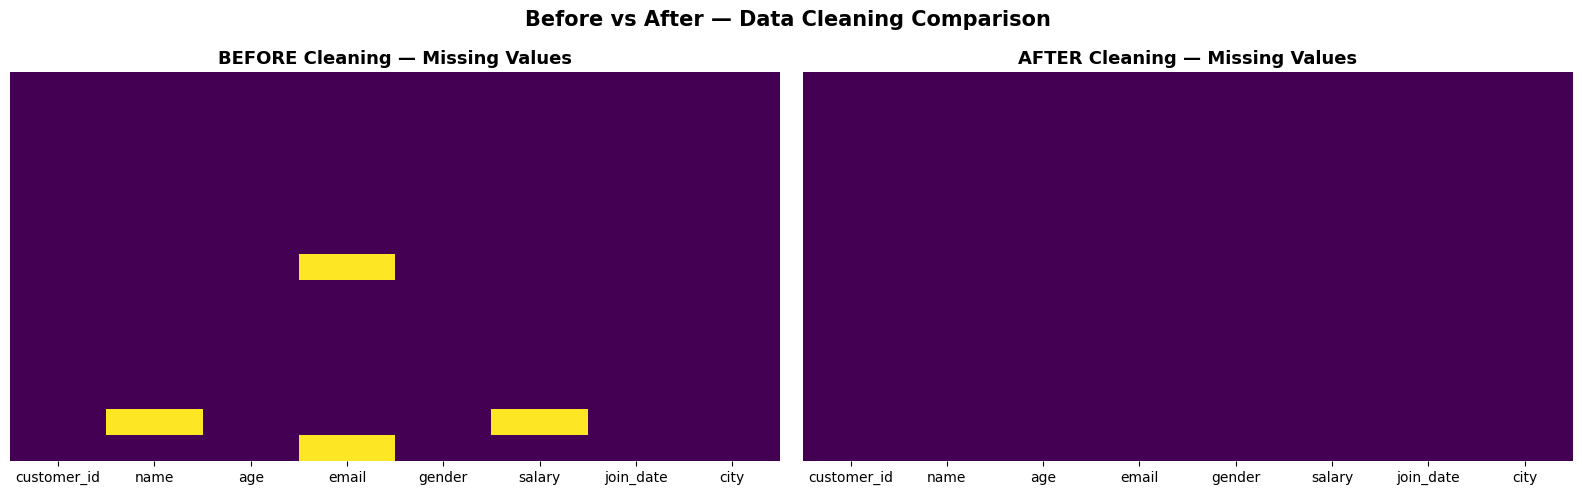

Comparison plot saved as 'cleaning_comparison.png'


In [17]:
# Adding missing imports for plotting
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',
            yticklabels=False, ax=axes[0])
axes[0].set_title('BEFORE Cleaning — Missing Values', fontsize=13, fontweight='bold')

# After
sns.heatmap(df_clean.isnull(), cbar=False, cmap='viridis',
            yticklabels=False, ax=axes[1])
axes[1].set_title('AFTER Cleaning — Missing Values', fontsize=13, fontweight='bold')

plt.suptitle('Before vs After — Data Cleaning Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaning_comparison.png', bbox_inches='tight')
plt.show()

print("Comparison plot saved as 'cleaning_comparison.png'")